In [1]:
import tensorflow as tf
import keras
import numpy as np

gpus = keras.distribution.list_devices(device_type="gpu")
print("Available GPUs:", gpus)

I0000 00:00:1790031132.689695    1438 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790031133.132456    1438 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790031134.763381    1438 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Available GPUs: ['gpu:0']


W0000 00:00:1790031136.857785    1438 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1790031136.858865    1438 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1790031136.991032    1438 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9217 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070, pci bus id: 0000:01:00.0, compute capability: 12.0a


## Import and quick analysis of dataset

In [2]:
from keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

## Build and train model to classify images on first subset

In [3]:
from keras.layers import Input, Dense, Flatten, Conv2D, MaxPooling2D, Dropout, BatchNormalization
from keras.models import Model

def build_model():
    inputs = Input(shape=(28, 28, 1))
    x = Conv2D(32, (3, 3), activation='gelu')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Conv2D(64, (3, 3), activation='gelu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu', name='intermediate_output')(x)
    x = keras.layers.UnitNormalization()(x)
    outputs = Dense(10, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model

model = build_model()
model.compile(optimizer='adamw', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.2, shuffle=True)

Epoch 1/10


I0000 00:00:1790031140.153102    1521 service.cc:153] XLA service 0x7f3e3c036c40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1790031140.153129    1521 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070, Compute Capability 12.0a (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.26.0)
I0000 00:00:1790031140.188128    1521 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1790031140.381304    1521 cuda_dnn.cc:461] Loaded cuDNN version 92600
I0000 00:00:1790031140.397194    1521 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2667__.40
I0000 00:00:1790031144.533320    1579 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion', 4 bytes spill stores, 4 bytes spill loads



 63/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7225 - loss: 1.6837

I0000 00:00:1790031146.088835    1521 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


733/750 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8470 - loss: 0.7968

I0000 00:00:1790031149.404081    1811 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 12 bytes spill stores, 12 bytes spill loads



750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8482 - loss: 0.7873 - val_accuracy: 0.8876 - val_loss: 0.4069
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9018 - loss: 0.3242 - val_accuracy: 0.8948 - val_loss: 0.3165
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9194 - loss: 0.2466 - val_accuracy: 0.9067 - val_loss: 0.2814
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9297 - loss: 0.2057 - val_accuracy: 0.9045 - val_loss: 0.2709
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9399 - loss: 0.1750 - val_accuracy: 0.8952 - val_loss: 0.2989
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9474 - loss: 0.1521 - val_accuracy: 0.9081 - val_loss: 0.2602
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9564 - loss: 0.1298 - val_accuracy: 0.9142 - val_loss: 0.2514
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9618 - loss: 0.1134 - val_accuracy: 0.8703 - val

## Quick evaluation of model on test data

In [4]:
scores = model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss: {scores[0]:.4f}")
print(f"Test accuracy: {scores[1]:.4f}")

Test loss: 0.3308
Test accuracy: 0.8890


## Build new dataset to use on siamese model

In [5]:
def make_balanced_pairs(X, y, n_pairs, rng):
    """Generate n_pairs pairs with ~50% positive (same class)"""
    classes = np.unique(y)
    idx_by_class = [np.flatnonzero(y == c) for c in classes]

    a = rng.integers(0, len(X), size=n_pairs)             # ancoras
    same = rng.integers(0, 2, size=n_pairs).astype(bool)  # rotulo decidido ANTES
    b = np.empty(n_pairs, dtype=int)

    for k, c in enumerate(classes):
        # positivos: segunda imagem da MESMA classe da ancora
        m = same & (y[a] == c)
        b[m] = rng.choice(idx_by_class[k], size=m.sum())
        # negativos: deslocamento de classe != 0 garante classe diferente
        m = ~same & (y[a] == c)
        other = (k + rng.integers(1, len(classes), size=m.sum())) % len(classes)
        b[m] = [rng.choice(idx_by_class[o]) for o in other]

    # evita par (i, i) nos positivos
    while True:
        dup = same & (a == b)
        if not dup.any():
            break
        for k, c in enumerate(classes):
            m = dup & (y[a] == c)
            if m.any():
                b[m] = rng.choice(idx_by_class[k], size=m.sum())
    y_pairs = same.astype(np.float32)
    y_pairs = 1.0 - y_pairs  # 1.0 para diferentes, 0.0 para iguais
    return a, b, y_pairs
rng = np.random.default_rng(42)
ia, ib, y_train_pairs = make_balanced_pairs(X_train, y_train, 60000, rng)
X_train_pairs = np.stack([X_train[ia], X_train[ib]], axis=1)

ia, ib, y_test_pairs = make_balanced_pairs(X_test, y_test, 10000, rng)
X_test_pairs = np.stack([X_test[ia], X_test[ib]], axis=1)

## Build new model and train it

In [6]:
new_model = keras.Model(inputs=model.input, outputs=model.layers[-2].output)
new_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ intermediate_output (Dense)     │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ unit_normalization              │ (None, 128)            │             0 │
│ (UnitNormalization)             │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 224,128 (875.50 KB)

 Trainable params: 223,936 (874.75 KB)

 Non-trainable params: 192 (768.00 B)

In [7]:
from keras.layers import Lambda
from keras_distance import euclidean_distance

MARGIN = 1.0


def build_siamese_distance_layer():
    input_a = Input(shape=(128,))
    input_b = Input(shape=(128,))

    # Compute the euclidean distance between the two embeddings
    diff = Lambda(euclidean_distance, output_shape=(1,), name='euclidean_distance')( [input_a, input_b] )

    return Model(inputs=[input_a, input_b], outputs=diff)


def loss_function(y_true, distance, margin: float=MARGIN):
    y_true = tf.reshape(tf.cast(y_true, distance.dtype), (-1,))
    distance = tf.reshape(distance, (-1,))
    return tf.reduce_mean((1 - y_true) * tf.square(distance) + y_true * tf.square(tf.maximum(0.0, margin - distance)))

def train_siamese_model(siamese_model, model, X, y, validation_split: float=0.2, epochs: int=10, batch_size: int=128):
    optimizer = keras.optimizers.AdamW(learning_rate=1e-4)
    X_val = X[int(len(X) * (1 - validation_split)):]
    y_val = y[int(len(y) * (1 - validation_split)):]
    X_train = X[:int(len(X) * (1 - validation_split))]
    y_train = y[:int(len(y) * (1 - validation_split))]
    accuracy_hist = {
        'train' : [],
        'val' : []
    }
    loss_hist = {
        'train' : [],
        'val' : []
    }

    for epoch in range(epochs):
        accuracy = 0.0
        loss = 0.0
        batch_count = 0
        perm = rng.permutation(len(X_train))
        print(f"Epoch {epoch + 1}/{epochs}")
        for i in range(0, len(X_train), batch_size):
            idx = perm[i:i + batch_size]
            X_batch = X_train[idx]
            y_batch = y_train[idx]

            with tf.GradientTape() as tape:
                embeddings_a = model(X_batch[:, 0], training=True)
                embeddings_b = model(X_batch[:, 1], training=True)
                distance = siamese_model([embeddings_a, embeddings_b], training=True)
                loss += loss_function(y_batch, distance)
                batch_count += 1
                accuracy += ((distance.numpy().ravel() > MARGIN/2) == (y_batch.ravel() == 1)).mean()

            gradients = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(gradients, model.trainable_variables))
        accuracy = accuracy / batch_count
        loss = loss / batch_count
        accuracy_hist['train'].append(accuracy)
        loss_hist['train'].append(loss)
        print(f"Training Accuracy: {accuracy:.4f} | Loss: {loss.numpy().mean():.4f}")


        val_embeddings_a = model(X_val[:, 0], training=False)
        val_embeddings_b = model(X_val[:, 1], training=False)
        val_y_pred = siamese_model([val_embeddings_a, val_embeddings_b], training=False)
        val_loss = loss_function(y_val, val_y_pred)
        val_acc = ((val_y_pred.numpy().ravel() > MARGIN/2) == (y_val.ravel() == 1)).mean()
        accuracy_hist['val'].append(val_acc)
        loss_hist['val'].append(val_loss)
        print(f"Validation Accuracy: {val_acc:.4f} | Loss: {val_loss.numpy().mean():.4f}")

    return accuracy_hist, loss_hist



In [8]:
siamese_model = build_siamese_distance_layer()
accuracy_hist, loss_hist = train_siamese_model(siamese_model, new_model, X_train_pairs, y_train_pairs, validation_split=0.2, epochs=10, batch_size=64)

Epoch 1/10
Training Accuracy: 0.7965 | Loss: 0.1550


W0000 00:00:1790031231.991319    1438 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 5.28GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


Validation Accuracy: 0.9011 | Loss: 0.0910
Epoch 2/10
Training Accuracy: 0.9213 | Loss: 0.0805
Validation Accuracy: 0.9316 | Loss: 0.0745
Epoch 3/10
Training Accuracy: 0.9345 | Loss: 0.0705
Validation Accuracy: 0.9364 | Loss: 0.0689
Epoch 4/10
Training Accuracy: 0.9405 | Loss: 0.0655
Validation Accuracy: 0.9403 | Loss: 0.0654
Epoch 5/10
Training Accuracy: 0.9445 | Loss: 0.0619
Validation Accuracy: 0.9433 | Loss: 0.0627
Epoch 6/10
Training Accuracy: 0.9475 | Loss: 0.0591
Validation Accuracy: 0.9432 | Loss: 0.0607
Epoch 7/10
Training Accuracy: 0.9498 | Loss: 0.0567
Validation Accuracy: 0.9464 | Loss: 0.0591
Epoch 8/10
Training Accuracy: 0.9524 | Loss: 0.0548
Validation Accuracy: 0.9462 | Loss: 0.0581
Epoch 9/10
Training Accuracy: 0.9538 | Loss: 0.0531
Validation Accuracy: 0.9477 | Loss: 0.0566
Epoch 10/10
Training Accuracy: 0.9558 | Loss: 0.0515
Validation Accuracy: 0.9494 | Loss: 0.0559


## Display results

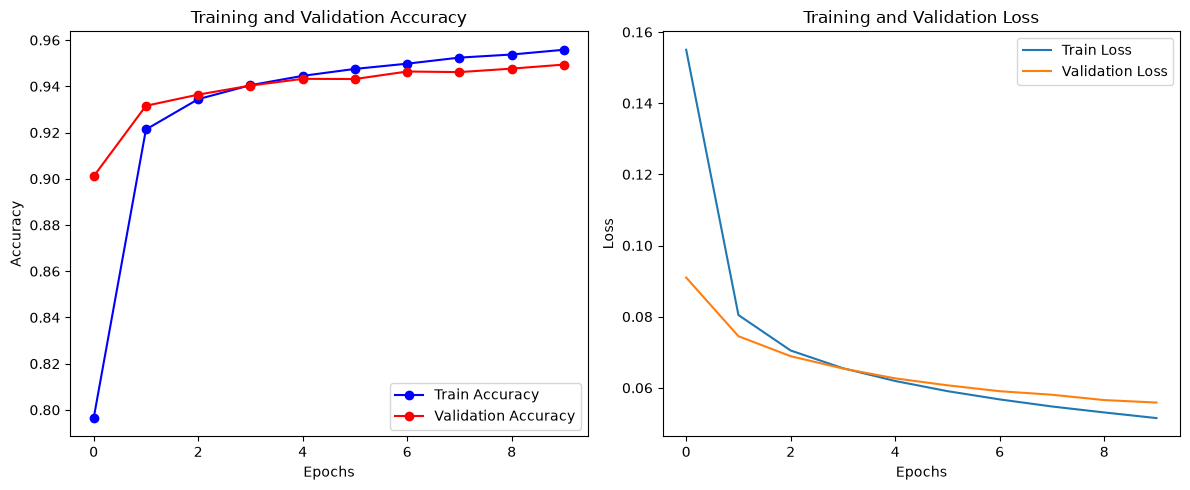

In [9]:
import matplotlib.pyplot as plt
def plot_training_history(accuracy_hist, loss_hist):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(accuracy_hist['train'], label='Train Accuracy', color='blue', marker='o')
    plt.plot(accuracy_hist['val'], label='Validation Accuracy', color='red', marker='o')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(loss_hist['train'], label='Train Loss')
    plt.plot(loss_hist['val'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_history(accuracy_hist, loss_hist)

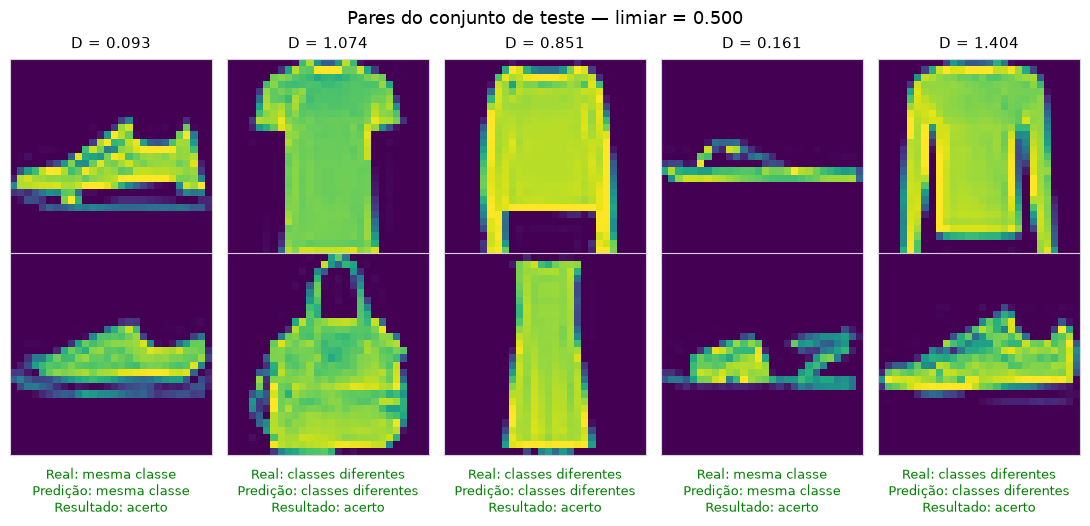

In [15]:
def plot_pair_examples(model, X_pairs, y_pairs, threshold, n=5, rng=None):
    rng = rng or np.random.default_rng()
    idx = rng.choice(len(X_pairs), size=n, replace=False)

    emb_a = model.predict(X_pairs[idx, 0], batch_size=512, verbose=0)
    emb_b = model.predict(X_pairs[idx, 1], batch_size=512, verbose=0)
    d = np.linalg.norm(emb_a - emb_b, axis=1)

    fig, axes = plt.subplots(2, n, figsize=(2.2 * n, 5.2))
    for k in range(n):
        for row in (0, 1):
            ax = axes[row, k]
            ax.imshow(np.squeeze(X_pairs[idx[k], row]), cmap='viridis', vmin=0, vmax=1)
            ax.set_xticks([]); ax.set_yticks([])
            for s in ax.spines.values():
                s.set_edgecolor('#d4d4d8')

        real = "mesma classe" if y_pairs[idx[k]] == 0 else "classes diferentes"
        pred = "mesma classe" if d[k] <= threshold else "classes diferentes"
        acertou = (real == pred)
        axes[0, k].set_title(f"D = {d[k]:.3f}", fontsize=11, pad=8)
        axes[1, k].set_xlabel(f"Real: {real}\nPredição: {pred}\n{'Resultado: acerto' if acertou else 'Resultado: erro'}",
                            fontsize=9, labelpad=8,
                            color='green' if acertou else 'red')

    fig.suptitle(f"Pares do conjunto de teste — limiar = {threshold:.3f}", fontsize=13)
    fig.tight_layout()
    return fig



plot_pair_examples(new_model, X_test_pairs, y_test_pairs, threshold=MARGIN/2, n=5, rng=rng)
plt.show()

In [11]:
new_model.save("fashion_mnist_model.keras")
siamese_model.save("fashion_mnist_siamese_model.keras")

In [13]:
def evaluate_siamese(siamese_model, model, X_pairs, y_pairs, threshold=MARGIN/2, batch_size=1024):
    emb_a = model.predict(X_pairs[:, 0], batch_size=batch_size, verbose=0)
    emb_b = model.predict(X_pairs[:, 1], batch_size=batch_size, verbose=0)
    d = siamese_model.predict([emb_a, emb_b], batch_size=batch_size, verbose=0).ravel()
    y = np.asarray(y_pairs).ravel()                     # 1 = classes diferentes

    loss = float(loss_function(y, tf.constant(d)))
    pred = (d > threshold).astype(np.float32)
    acc  = float((pred == y).mean())
    tp = ((pred == 1) & (y == 1)).sum(); fp = ((pred == 1) & (y == 0)).sum()
    fn = ((pred == 0) & (y == 1)).sum()
    prec = tp / max(tp + fp, 1); rec = tp / max(tp + fn, 1)
    return {"loss": loss, "accuracy": acc, "precision": prec, "recall": rec,
            "f1": 2*prec*rec/max(prec+rec, 1e-9),
            "d_mesma_classe": d[y == 0].mean(), "d_classes_diferentes": d[y == 1].mean()}, d, y

metrics, d, y = evaluate_siamese(siamese_model, new_model, X_test_pairs, y_test_pairs)

In [14]:
print(metrics)

{'loss': 0.06342733651399612, 'accuracy': 0.9346, 'precision': np.float64(0.9237763590636486), 'recall': np.float64(0.9483614697120158), 'f1': np.float64(0.935907487259898), 'd_mesma_classe': np.float32(0.24369831), 'd_classes_diferentes': np.float32(1.0704281)}
